# Кросс-валидация

## Цель работы

Познакомиться с основными типами разбиений данных при осуществлении кросс-валидации с использованием библиотеки sklearn.

## 1. Загрузка данных

Загрузим известный датасет **Ирисы Фишера** из sklearn.

In [36]:
import pandas as pd
from sklearn.datasets import load_iris

iris = load_iris()
X = iris.data
y = iris.target

Преобразуем данные в DataFrame для наглядности:

In [37]:
iris_data = pd.DataFrame(iris['data'], columns=iris['feature_names'])
name_map = {0: 'Iris-setosa', 1: 'Iris-versicolor', 2:'Iris-virginica'}
iris_data['class'] = [name_map[k] for k in iris['target']]
iris_data.head(10)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),class
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa
5,5.4,3.9,1.7,0.4,Iris-setosa
6,4.6,3.4,1.4,0.3,Iris-setosa
7,5.0,3.4,1.5,0.2,Iris-setosa
8,4.4,2.9,1.4,0.2,Iris-setosa
9,4.9,3.1,1.5,0.1,Iris-setosa


## 2. Hold-out разбиение и обучение модели

### Разбиение 85/15 (random_state=5)

In [38]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.15, random_state=5)

Обучим модель логистической регрессии и выведем метрики:

In [39]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

model = LogisticRegression(solver='lbfgs', max_iter=1000)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print(accuracy_score(y_test, y_pred))
print(f1_score(y_test, y_pred, average='macro'))

0.9130434782608695
0.9074074074074074


Построим матрицу ошибок:

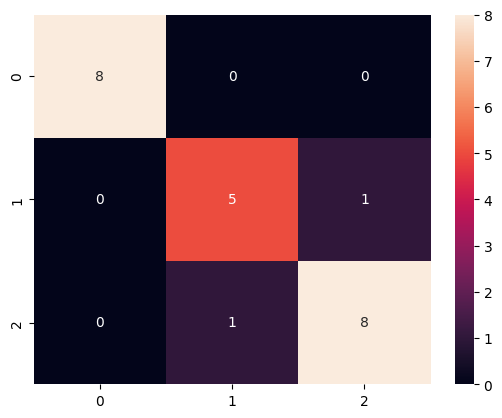

In [40]:
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True)
plt.show()

### Разбиение 85/15 (random_state=0)

Повторим с другим random_state:

In [41]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.15, random_state=0)
model = LogisticRegression(solver='lbfgs', max_iter=1000)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print(accuracy_score(y_test, y_pred))
print(f1_score(y_test, y_pred, average='macro'))

1.0
1.0


Матрица ошибок:

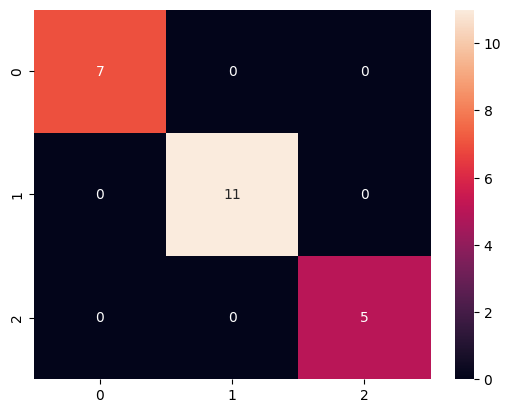

In [42]:
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True)
plt.show()

### Разбиение 85/15 (random_state=8)

Ещё одно разбиение:

In [43]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.15, random_state=8)
model = LogisticRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print(accuracy_score(y_test, y_pred))
print(f1_score(y_test, y_pred, average='macro'))

0.8695652173913043
0.8745098039215686


Матрица ошибок:

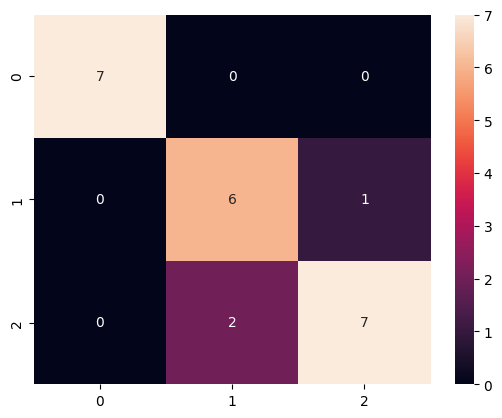

In [44]:
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True)
plt.show()

## 3. k-fold разбиение

Импортируем необходимые библиотеки:

In [45]:
from sklearn.model_selection import KFold, StratifiedKFold, LeaveOneOut, cross_val_score

Создадим k-блочное разбиение (KFold, k=3):

In [46]:
kf = KFold(n_splits=3, shuffle=True, random_state=15)
kf

KFold(n_splits=3, random_state=15, shuffle=True)

Выполним разбиение и выведем индексы:

In [47]:
for i, (train_index, test_index) in enumerate(kf.split(y)):
    print("Fold {}: Длина train: {}, Длина test: {}".format(i+1, len(train_index), len(test_index)))
    print('Train: index={}\n Test:  index={}'.format(train_index, test_index))
    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index], y[test_index]

Fold 1: Длина train: 100, Длина test: 50
Train: index=[  1   2   3   4   7  10  14  15  16  17  18  19  22  23  24  26  28  29
  32  33  34  35  37  38  39  40  41  42  43  44  45  46  49  50  51  52
  53  54  56  60  62  63  64  65  66  68  69  70  73  75  76  77  79  80
  81  82  83  85  87  88  91  92  93  94  96  99 101 102 104 105 106 107
 108 110 111 113 114 117 118 119 120 121 123 125 128 131 132 133 134 135
 136 137 139 140 141 142 144 145 146 147]
 Test:  index=[  0   5   6   8   9  11  12  13  20  21  25  27  30  31  36  47  48  55
  57  58  59  61  67  71  72  74  78  84  86  89  90  95  97  98 100 103
 109 112 115 116 122 124 126 127 129 130 138 143 148 149]
Fold 2: Длина train: 100, Длина test: 50
Train: index=[  0   1   4   5   6   7   8   9  10  11  12  13  15  17  19  20  21  22
  23  24  25  26  27  28  30  31  34  36  37  39  40  41  42  44  47  48
  50  53  55  56  57  58  59  60  61  62  63  65  66  67  70  71  72  74
  75  78  79  84  85  86  89  90  95  96  97  98

Выполним кросс-валидацию вручную:

In [48]:
metrics_accuracy = []
metrics_f1 = []
model = LogisticRegression(solver='lbfgs', max_iter=1000)
for i, (train_index, test_index) in enumerate(kf.split(y)):
    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index], y[test_index]
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    metrics_accuracy.append(accuracy_score(y_test, y_pred))
    metrics_f1.append(f1_score(y_test, y_pred, average='macro'))

Выведем метрики:

In [49]:
print('Значения метрики accuracy: {} \nЗначения метрики f1: {}'.format(metrics_accuracy, metrics_f1))

Значения метрики accuracy: [1.0, 0.94, 0.94] 
Значения метрики f1: [1.0, 0.9444015444015443, 0.9352142110762801]


Среднее значение метрики f1:

In [50]:
import numpy as np
print("Среднее по кросс-валидации: ", np.array(metrics_f1).mean())

Среднее по кросс-валидации:  0.9598719184926082


### Кросс-валидация с помощью cross_val_score

In [51]:
cv_results = cross_val_score(model,                  # модель
                             X,                      # матрица признаков
                             y,                      # вектор цели
                             cv=kf,                  # тип разбиения
                             scoring='accuracy',     # метрика
                             n_jobs=-1)              # используются все ядра CPU

print("Кросс-валидация: ", cv_results)
print("Среднее по кросс-валидации: ", cv_results.mean())
print("Дисперсия по кросс-валидации: ", cv_results.std())

Кросс-валидация:  [1.   0.94 0.94]
Среднее по кросс-валидации:  0.96
Дисперсия по кросс-валидации:  0.028284271247461926


## 4. Stratified k-Fold

Стратифицированное разбиение сохраняет соотношение классов в каждом фолде.

In [52]:
skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=15)
skf.get_n_splits(X, y)

3

Выведем разбиение на блоки:

In [53]:
for i, (train_index, test_index) in enumerate(skf.split(X, y)):
    print(f"Fold {i+1}:")
    print('Train: index={}\n Test:  index={}'.format(train_index, test_index))
    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index], y[test_index]

Fold 1:
Train: index=[  0   1   2   3   4   5   7   8   9  12  14  15  16  17  18  19  21  23
  24  25  26  28  29  31  32  36  37  38  39  40  41  44  45  51  52  53
  54  55  60  61  62  63  65  66  68  70  72  75  77  80  81  82  83  84
  85  86  87  89  90  91  93  94  95  96  97  98 101 102 103 104 105 107
 110 111 112 113 114 116 118 121 122 123 124 126 127 128 129 132 133 134
 139 140 141 142 143 144 145 146 147 149]
 Test:  index=[  6  10  11  13  20  22  27  30  33  34  35  42  43  46  47  48  49  50
  56  57  58  59  64  67  69  71  73  74  76  78  79  88  92  99 100 106
 108 109 115 117 119 120 125 130 131 135 136 137 138 148]
Fold 2:
Train: index=[  0   1   2   4   5   6   9  10  11  13  14  15  16  19  20  21  22  23
  26  27  28  29  30  31  33  34  35  42  43  46  47  48  49  50  51  54
  55  56  57  58  59  61  63  64  66  67  69  70  71  73  74  75  76  78
  79  83  84  87  88  89  90  91  92  94  96  97  99 100 101 103 105 106
 107 108 109 110 114 115 116 117 118 119 

Кросс-валидация с помощью cross_val_score (straified):

In [54]:
cv_results = cross_val_score(model,
                             X,
                             y,
                             cv=skf,
                             scoring='f1_macro',
                             n_jobs=-1)

print("Кросс-валидация: ", cv_results)
print("Среднее по кросс-валидации: ", cv_results.mean())

Кросс-валидация:  [0.95925926 0.95955882 0.96064815]
Среднее по кросс-валидации:  0.9598220769789397


## 5. Leave-One-Out (LOO)

Leave-one-out — частный случай k-Fold, где каждый фолд состоит ровно из одного объекта.

In [55]:
loo = LeaveOneOut()

Выведем разбиение на блоки (первые несколько фолдов):

In [56]:
for i, (train_index, test_index) in enumerate(loo.split(X)):
    if i >= 3:
        break
    print(f"Fold {i+1}:")
    print('Train: index={}\n Test:  index={}'.format(train_index[:10], test_index))
    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index], y[test_index]

Fold 1:
Train: index=[ 1  2  3  4  5  6  7  8  9 10]
 Test:  index=[0]
Fold 2:
Train: index=[ 0  2  3  4  5  6  7  8  9 10]
 Test:  index=[1]
Fold 3:
Train: index=[ 0  1  3  4  5  6  7  8  9 10]
 Test:  index=[2]


Кросс-валидация с помощью cross_val_score (LOO):

In [57]:
cv_results = cross_val_score(model,
                             X,
                             y,
                             cv=loo,
                             scoring='f1_macro',
                             n_jobs=-1)

print("Кросс-валидация (первые 10): ", cv_results[:10])
print("Среднее по кросс-валидации: ", cv_results.mean())

Кросс-валидация (первые 10):  [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
Среднее по кросс-валидации:  0.9666666666666667
